# 02 - Kiểm thử Module Features
Kiểm tra việc phân khung tín hiệu (Framing), trích xuất năng lượng ngắn hạn (STE/MA) và ước lượng cao độ F0 (Pitch).


In [5]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

ROOT_DIR = Path.cwd().resolve()
while ROOT_DIR.name != 'main_gk' and ROOT_DIR.parent != ROOT_DIR:
    ROOT_DIR = ROOT_DIR.parent
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

from src.audio.dataset import load_dataset
from src.features.framing import apply_framing
from src.features.extraction import extract_features, compute_ste, compute_ma
from src.features.pitch import estimate_f0_track


### 1. Kiểm tra phân khung tín hiệu (Framing: 25ms, shift 10ms)


In [6]:
signals = load_dataset(ROOT_DIR / 'TinHieuKiemThu')
sig = signals[0]  # phone_F2

framed = apply_framing(sig, frame_size_ms=25.0, frame_shift_ms=10.0)
print(f'Tín hiệu: {sig.name} ({sig.duration_sec:.2f}s)')
print(f'Số lượng khung       : {len(framed.timestamps)}')
print(f'Độ dài mỗi khung (mẫu): {framed.frame_len}')
print(f'Bước nhảy (mẫu)      : {framed.frame_shift}')
print(f'Mốc thời gian 5 khung đầu: {framed.timestamps[:5]}')


Tín hiệu: phone_F2 (4.80s)
Số lượng khung       : 478
Độ dài mỗi khung (mẫu): 400
Bước nhảy (mẫu)      : 160
Mốc thời gian 5 khung đầu: [0.0125 0.0225 0.0325 0.0425 0.0525]


### 2. Kiểm tra tính năng lượng ngắn hạn (STE / MA chuẩn hóa)


Mảng STE chuẩn hóa shape: (478,)
Min STE: 0.0000, Max STE: 1.0000


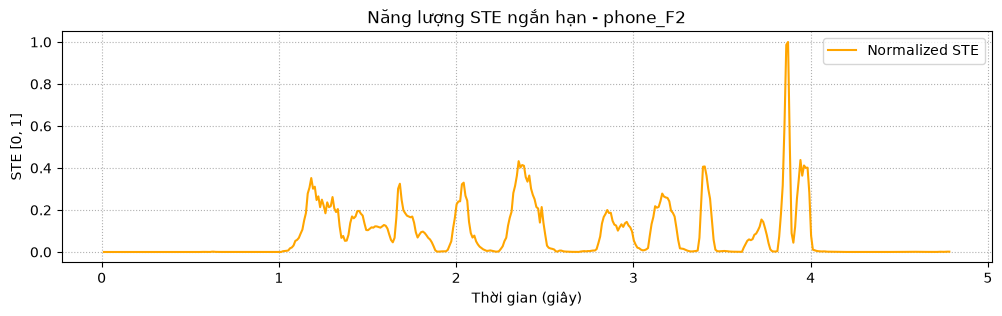

In [7]:
feats = extract_features(framed)
print(f'Mảng STE chuẩn hóa shape: {feats.ste_norm.shape}')
print(f'Min STE: {feats.ste_norm.min():.4f}, Max STE: {feats.ste_norm.max():.4f}')

# Vẽ thử đồ thị STE ngắn hạn
plt.figure(figsize=(12, 3))
plt.plot(framed.timestamps, feats.ste_norm, color='orange', label='Normalized STE')
plt.title(f'Năng lượng STE ngắn hạn - {sig.name}')
plt.xlabel('Thời gian (giây)')
plt.ylabel('STE [0, 1]')
plt.grid(True, linestyle=':')
plt.legend()
plt.show()


### 3. Kiểm tra ước lượng cao độ F0 (Pitch Tracking bằng Tự tương quan)


Tổng số khung có Pitch: 274 / 478
F0 trung bình: 172.7 Hz, Min: 60.2 Hz, Max: 400.0 Hz


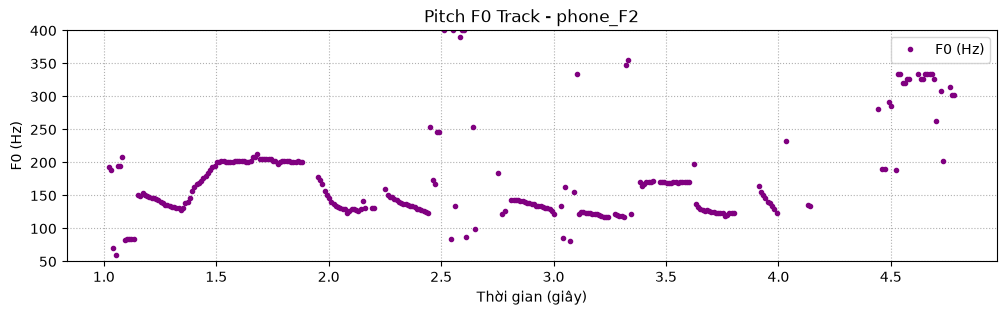

In [8]:
f0 = estimate_f0_track(sig.signal, sig.fs, framed.timestamps, framed.frame_len)
valid_f0 = f0[~np.isnan(f0)]
print(f'Tổng số khung có Pitch: {len(valid_f0)} / {len(f0)}')
if len(valid_f0) > 0:
    print(f'F0 trung bình: {np.mean(valid_f0):.1f} Hz, Min: {np.min(valid_f0):.1f} Hz, Max: {np.max(valid_f0):.1f} Hz')

plt.figure(figsize=(12, 3))
plt.plot(framed.timestamps, f0, 'o', color='purple', markersize=3, label='F0 (Hz)')
plt.title(f'Pitch F0 Track - {sig.name}')
plt.xlabel('Thời gian (giây)')
plt.ylabel('F0 (Hz)')
plt.ylim(50, 400)
plt.grid(True, linestyle=':')
plt.legend()
plt.show()
